# Heatmap de contacts (table 4) — clusters cluster_data_70

Pour chaque cluster `cluster_data_70` :
- **Si tous les S2 appartiennent au même cluster séquence** → **un seul heatmap** avec toutes les interactions (`{patch}_all.png`)
- **Si les S2 viennent de clusters séquence différents** → **un heatmap par cluster S2** (`{patch}_{s2_cluster}.png`)

**Axes :**
- **X** = positions canoniques MAFFT côté A (actin)
- **Y** = positions canoniques MAFFT côté B (partenaire)
- **Couleur** = fraction des interactions présentant ce contact

**Note technique** : `df_c70` utilise les `interaction_id` de `df_summary` (espace 7–4562),  
tandis que `df4` (contacts) utilise les `interaction_id` de `df_int1` (espace 1–1991).  
Le mapping `summ_to_int1` assure la traduction entre les deux espaces.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from pathlib import Path

DATA     = Path('../data')
FILTERED = DATA / 'filtered'
DETAILS  = FILTERED / 'details'
OUT_DIR  = Path('../visualisations') / 'actin_c70_contacts'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Données
df_all     = pd.read_csv(FILTERED / 'filtered_all_data.csv')
df_summary = pd.read_csv(FILTERED / 'filtered_summary.csv')
df_int1    = pd.read_csv(DETAILS / '1.interactions.csv')
df_res4    = pd.read_csv(DETAILS / '4.inter-residue_contacts.csv')
df_c70     = pd.read_csv(FILTERED / 'patches_infos_cluster_data_70.csv')

# df_merged : même construction que dans mafft_alignment.ipynb
# → donne interaction_id (espace df_summary) + s2_sequence_cluster_70 (depuis df_all)
df_merged = df_all.merge(
    df_summary,
    left_on=['subunit_1', 'subunit_2'],
    right_on=['Protein ID', 'Interactor ID'],
    how='left'
)

# Mapping summ_id → s2_sequence_cluster_70 (dédupliqué pour éviter ValueError sur reindex)
iid_to_s2clust = (
    df_merged
    .drop_duplicates('interaction_id')
    .set_index('interaction_id')['s2_sequence_cluster_70']
)

# ─────────────────────────────────────────────────────────────────────────────
# df4 (contacts) utilise les interaction_id de df_int1 (1–1991),
# différents de ceux de df_summary (7–4562) utilisés par df_c70.
# On construit un dict summ_id → int1_id pour la traduction.
# ─────────────────────────────────────────────────────────────────────────────
summ_to_int1 = (
    df_summary[['interaction_id', 'PDB ID', 'Protein ID', 'Interactor ID']]
    .rename(columns={'PDB ID': 'pdb_id', 'interaction_id': 'summ_id'})
    .merge(
        df_int1[['interaction_id', 'pdb_id', 'chain_A_id', 'chain_B_id']]
        .rename(columns={'interaction_id': 'int1_id'}),
        left_on=['pdb_id', 'Protein ID', 'Interactor ID'],
        right_on=['pdb_id', 'chain_A_id', 'chain_B_id'],
        how='left'
    )
    .dropna(subset=['int1_id'])
    .set_index('summ_id')['int1_id']
    .astype(int)
    .to_dict()   # dict Python : {summ_id: int1_id}
)

# Table 4 : garder seulement les contacts avec canon des deux côtés
df4 = df_res4[
    df_res4['residue_A_canon_mafft'].notna() &
    df_res4['residue_B_canon_mafft'].notna()
].copy()
df4['canon_A'] = df4['residue_A_canon_mafft'].astype(int)
df4['canon_B'] = df4['residue_B_canon_mafft'].astype(int)

print(f'df_merged                : {len(df_merged)} lignes')
print(f'Mapping summ→s2clust OK  : {iid_to_s2clust.notna().sum()}/{len(iid_to_s2clust)}')
print(f'Mapping summ→int1 complet: {len(summ_to_int1)}/{len(df_summary)}')
print(f'Contacts (table 4)       : {len(df4)} (avec canon A et B)')
print(f'Clusters c70             : {len(df_c70)}')

df_merged                : 2250 lignes
Mapping summ→s2clust OK  : 1326/1326
Mapping summ→int1 complet: 1325/2250
Contacts (table 4)       : 137143 (avec canon A et B)
Clusters c70             : 255


In [2]:
def parse_ids(s):
    return set(int(x) for x in re.findall(r'\d+', str(s)))

cluster_list = []
for _, row in df_c70.iterrows():
    ids = parse_ids(row['ids_interactions'])
    # Tous les groupes S2 présents dans ce cluster
    s2_map = iid_to_s2clust.reindex(list(ids)).dropna()
    groups = s2_map.value_counts()   # s2_cluster → nb interactions, trié desc
    cluster_list.append({
        'patch':        row['patch'],
        'type':         row.get('interaction_type', '?'),
        'n':            row['n_interactions'],
        'iids':         ids,
        'groups':       groups.index.tolist(),   # TOUS les s2 sequence clusters
        'group_counts': groups.to_dict(),
    })

cluster_list.sort(key=lambda x: -x['n'])
print('\nExemple (premiers clusters) :')
for c in cluster_list[:5]:
    print(f"  {str(c['patch']):25s}  n={c['n']:4d}  S2 clusters ({len(c['groups'])}) : {c['groups']}")


Exemple (premiers clusters) :
  0_7797_0                   n= 672  S2 clusters (1) : [6685.0]
  0_7797_1                   n= 535  S2 clusters (1) : [6685.0]
  0_30351_1                  n=  74  S2 clusters (1) : [29177.0]
  0_30351_0                  n=  62  S2 clusters (1) : [29177.0]
  0_7797_12                  n=  54  S2 clusters (1) : [6685.0]


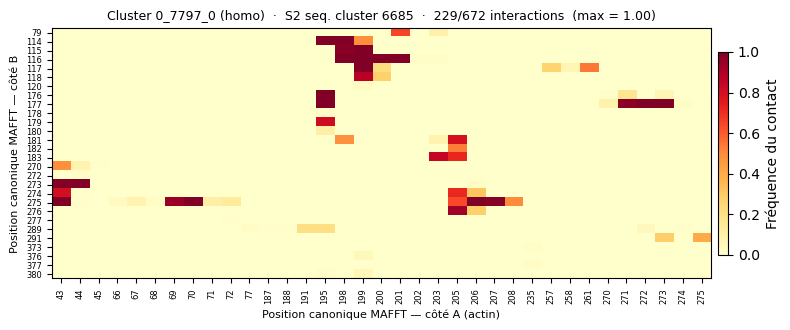

In [3]:
def contact_freq_matrix(int1_ids, df4_sub):
    """Matrice de fréquence de contact : canon_A × canon_B."""
    n = len(int1_ids)
    if df4_sub.empty or n == 0:
        return None, None, None
    pairs = (
        df4_sub.groupby(['interaction_id', 'canon_A', 'canon_B'])
        .size().reset_index(name='_')
    )
    freq = (
        pairs.groupby(['canon_A', 'canon_B'])['interaction_id']
        .nunique()
        .reset_index(name='count')
    )
    freq['freq'] = freq['count'] / n
    pos_A = sorted(freq['canon_A'].unique())
    pos_B = sorted(freq['canon_B'].unique())
    mat = np.zeros((len(pos_B), len(pos_A)))
    idx_A = {v: i for i, v in enumerate(pos_A)}
    idx_B = {v: i for i, v in enumerate(pos_B)}
    for _, r in freq.iterrows():
        mat[idx_B[r['canon_B']], idx_A[r['canon_A']]] = r['freq']
    return mat, pos_A, pos_B


def _fmt_s2(s2_clust):
    try:
        v = float(s2_clust)
        return str(int(v)) if v == int(v) else str(v)
    except (ValueError, TypeError):
        return str(s2_clust)


CELL_W  = 0.05
CELL_H  = 0.05
FIG_W_MIN = 8
FIG_H_MIN = 3
FIG_W_MAX = 20
FIG_H_MAX = 15


def plot_group(patch, inter_type, s2_clust, iids_g, n_total, save=True):
    n_g = len(iids_g)
    s2_str = _fmt_s2(s2_clust)

    int1_ids = {summ_to_int1[i] for i in iids_g if i in summ_to_int1}
    df4_g = df4[df4['interaction_id'].isin(int1_ids)]

    mat, pos_A, pos_B = contact_freq_matrix(int1_ids, df4_g)

    n_A = len(pos_A) if pos_A else 10
    n_B = len(pos_B) if pos_B else 5
    fig_w = min(FIG_W_MAX, max(FIG_W_MIN, n_A * CELL_W + 3))
    fig_h = min(FIG_H_MAX, max(FIG_H_MIN, n_B * CELL_H + 2))

    vmax_str = f'{mat.max():.2f}' if mat is not None else '0'
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    if mat is None:
        ax.text(0.5, 0.5, 'Pas de données', ha='center', va='center', transform=ax.transAxes)
    else:
        vmax = mat.max()
        im = ax.imshow(mat, aspect='auto', cmap='YlOrRd',
                       interpolation='none', vmin=0, vmax=vmax)
        step_A = max(1, n_A // 40)
        ax.set_xticks(range(0, n_A, step_A))
        ax.set_xticklabels([pos_A[i] for i in range(0, n_A, step_A)], fontsize=6, rotation=90)
        ax.set_xlabel('Position canonique MAFFT — côté A (actin)', fontsize=8)
        step_B = max(1, n_B // 30)
        ax.set_yticks(range(0, n_B, step_B))
        ax.set_yticklabels([pos_B[i] for i in range(0, n_B, step_B)], fontsize=6)
        ax.set_ylabel('Position canonique MAFFT — côté B', fontsize=8)
        plt.colorbar(im, ax=ax, fraction=0.015, pad=0.01, label='Fréquence du contact')

    ax.set_title(
        f'Cluster {patch} ({inter_type})  ·  S2 seq. cluster {s2_str}  '
        f'·  {n_g}/{n_total} interactions  (max = {vmax_str})',
        fontsize=9
    )
    plt.tight_layout()

    if save:
        out = OUT_DIR / f'{patch}_{s2_str}.png'
        plt.savefig(out, dpi=150, bbox_inches='tight')
        plt.close(fig)
        return str(out)
    else:
        plt.show()
        plt.close(fig)
        return None

# Aperçu : premier cluster, premier groupe S2
c = cluster_list[0]
s2 = c['groups'][0]
iids_g = {iid for iid in c['iids'] if iid_to_s2clust.get(iid) == s2}
plot_group(c['patch'], c['type'], s2, iids_g, c['n'], save=False)

In [4]:
for old_f in OUT_DIR.glob('*.png'):
    old_f.unlink()
print("Anciens fichiers supprimés")

count = 0
for clust in cluster_list:
    for s2_clust in clust['groups']:
        iids_g = {iid for iid in clust['iids'] if iid_to_s2clust.get(iid) == s2_clust}
        plot_group(clust['patch'], clust['type'], s2_clust, iids_g, clust['n'], save=True)
        count += 1

print(f'{count} images sauvegardées → {OUT_DIR}/')

Anciens fichiers supprimés


247 images sauvegardées → ../visualisations/actin_c70_contacts/


In [5]:
import json as _json

group_counts = {
    str(clust['patch']): {str(int(float(k))): v for k, v in clust['group_counts'].items()}
    for clust in cluster_list
}

counts_path = OUT_DIR / 'group_counts.json'
with open(counts_path, 'w') as fh:
    _json.dump(group_counts, fh)
print(f'group_counts.json sauvegardé → {counts_path}')
print(f'{len(group_counts)} clusters, exemple :', list(group_counts.items())[:3])

group_counts.json sauvegardé → ../visualisations/actin_c70_contacts/group_counts.json


255 clusters, exemple : [('0_7797_0', {'6685': 229}), ('0_7797_1', {'6685': 163}), ('0_30351_1', {'29177': 74})]


## Heatmap surface area de contact — clusters C70

Même structure que les heatmaps de fréquence, mais la couleur représente la **surface area de contact moyenne (Å²)** par paire de positions canoniques (A × B), calculée depuis la colonne `contact_area` de la table 4.

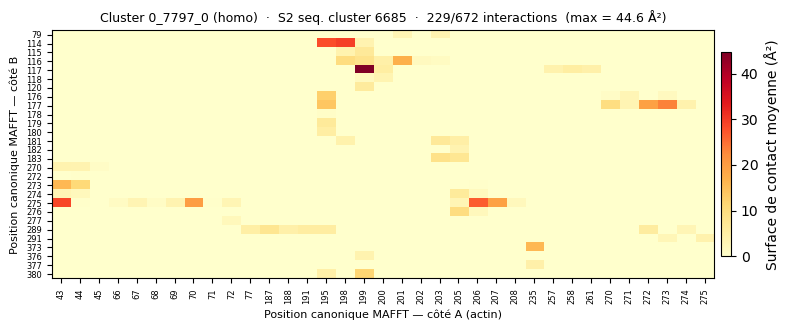

In [6]:
OUT_DIR_AREA = Path('../visualisations') / 'actin_c70_contacts_surface_area'
OUT_DIR_AREA.mkdir(parents=True, exist_ok=True)

df4['contact_area_num'] = pd.to_numeric(df4['contact_area'], errors='coerce')


def contact_area_matrix(int1_ids, df4_sub):
    """Matrice de surface area de contact moyenne (Å²) : canon_A × canon_B."""
    if df4_sub.empty or not int1_ids:
        return None, None, None
    area = (
        df4_sub.groupby(['canon_A', 'canon_B'])['contact_area_num']
        .mean()
        .reset_index(name='mean_area')
    )
    area = area.dropna(subset=['mean_area'])
    if area.empty:
        return None, None, None
    pos_A = sorted(area['canon_A'].unique())
    pos_B = sorted(area['canon_B'].unique())
    mat = np.zeros((len(pos_B), len(pos_A)))
    idx_A = {v: i for i, v in enumerate(pos_A)}
    idx_B = {v: i for i, v in enumerate(pos_B)}
    for _, r in area.iterrows():
        mat[idx_B[r['canon_B']], idx_A[r['canon_A']]] = r['mean_area']
    return mat, pos_A, pos_B


def plot_group_area(patch, inter_type, s2_clust, iids_g, n_total, save=True):
    n_g = len(iids_g)
    s2_str = _fmt_s2(s2_clust)

    int1_ids = {summ_to_int1[i] for i in iids_g if i in summ_to_int1}
    df4_g = df4[df4['interaction_id'].isin(int1_ids)]

    mat, pos_A, pos_B = contact_area_matrix(int1_ids, df4_g)

    n_A = len(pos_A) if pos_A else 10
    n_B = len(pos_B) if pos_B else 5
    fig_w = min(FIG_W_MAX, max(FIG_W_MIN, n_A * CELL_W + 3))
    fig_h = min(FIG_H_MAX, max(FIG_H_MIN, n_B * CELL_H + 2))

    vmax_str = f'{mat.max():.1f} Å²' if mat is not None else '0'
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    if mat is None:
        ax.text(0.5, 0.5, 'Pas de données', ha='center', va='center', transform=ax.transAxes)
    else:
        vmax = mat.max()
        im = ax.imshow(mat, aspect='auto', cmap='YlOrRd',
                       interpolation='none', vmin=0, vmax=vmax)
        step_A = max(1, n_A // 40)
        ax.set_xticks(range(0, n_A, step_A))
        ax.set_xticklabels([pos_A[i] for i in range(0, n_A, step_A)], fontsize=6, rotation=90)
        ax.set_xlabel('Position canonique MAFFT — côté A (actin)', fontsize=8)
        step_B = max(1, n_B // 30)
        ax.set_yticks(range(0, n_B, step_B))
        ax.set_yticklabels([pos_B[i] for i in range(0, n_B, step_B)], fontsize=6)
        ax.set_ylabel('Position canonique MAFFT — côté B', fontsize=8)
        plt.colorbar(im, ax=ax, fraction=0.015, pad=0.01, label='Surface de contact moyenne (Å²)')

    ax.set_title(
        f'Cluster {patch} ({inter_type})  ·  S2 seq. cluster {s2_str}  '
        f'·  {n_g}/{n_total} interactions  (max = {vmax_str})',
        fontsize=9
    )
    plt.tight_layout()

    if save:
        out = OUT_DIR_AREA / f'{patch}_{s2_str}.png'
        plt.savefig(out, dpi=150, bbox_inches='tight')
        plt.close(fig)
        return str(out)
    else:
        plt.show()
        plt.close(fig)
        return None

# Aperçu : premier cluster, premier groupe S2
c = cluster_list[0]
s2 = c['groups'][0]
iids_g = {iid for iid in c['iids'] if iid_to_s2clust.get(iid) == s2}
plot_group_area(c['patch'], c['type'], s2, iids_g, c['n'], save=False)

In [7]:
for old_f in OUT_DIR_AREA.glob('*.png'):
    old_f.unlink()
print("Anciens fichiers supprimés")

count = 0
for clust in cluster_list:
    for s2_clust in clust['groups']:
        iids_g = {iid for iid in clust['iids'] if iid_to_s2clust.get(iid) == s2_clust}
        plot_group_area(clust['patch'], clust['type'], s2_clust, iids_g, clust['n'], save=True)
        count += 1

print(f'{count} images sauvegardées → {OUT_DIR_AREA}/')

Anciens fichiers supprimés


247 images sauvegardées → ../visualisations/actin_c70_contacts_surface_area/


## Surface area par position canonique — clusters C70

Même analyse que `interface_analysis_s1.ipynb` mais groupée par cluster C70.  
Pour chaque cluster : **surface area moyenne (buried_ASA_Å²) côté S1 (chain_A)** par position canonique MAFFT, normalisée par le max de la ligne.

In [8]:
from scipy.cluster.hierarchy import linkage, leaves_list

df_res3 = pd.read_csv(DETAILS / '3.interface_residues.csv')
df_int1_full = pd.read_csv(DETAILS / '1.interactions.csv')

# Résidus côté S1 uniquement (chain_A) avec position canonique
s1_chain_map = df_int1_full.set_index('interaction_id')['chain_A_id'].str.lower()
df_res3['s1_chain'] = df_res3['interaction_id'].map(s1_chain_map)
df_res3['buried_ASA_Å²'] = pd.to_numeric(df_res3['buried_ASA_Å²'], errors='coerce')

df_res_s1 = df_res3[
    df_res3['residue_number_canon_mafft'].notna() &
    (df_res3['chain'].str.lower() == df_res3['s1_chain'])
].copy()
df_res_s1['canon'] = df_res_s1['residue_number_canon_mafft'].astype(int)

all_pos = sorted(df_res_s1['canon'].unique())
print(f'Résidus S1 avec canon : {len(df_res_s1)}')
print(f'Positions canoniques  : {len(all_pos)}  (de {min(all_pos)} à {max(all_pos)})')

# Mapping summ_id → int1_id (interaction_id dans table 3 = espace df_int1)
# cluster_list utilise les summ_ids → on traduit en int1_ids pour rejoindre df_res3
summ_to_int1_series = pd.Series(summ_to_int1)  # summ_id → int1_id

Résidus S1 avec canon : 55777
Positions canoniques  : 306  (de 1 à 405)


In [9]:
MARGIN_L = 2.2
MARGIN_R = 0.6
MARGIN_B = 1.4
MARGIN_T = 0.25
ROW_H    = 0.13   # hauteur par ligne (pouces) — même que le notebook S1

homo_c70, hetero_c70 = [], []

for c in cluster_list:
    # Traduit les summ_ids en int1_ids
    int1_ids = {summ_to_int1[i] for i in c['iids'] if i in summ_to_int1}
    entry = {**c, 'int1_ids': int1_ids}
    if str(c['type']).lower() == 'homo':
        homo_c70.append(entry)
    else:
        hetero_c70.append(entry)

homo_c70.sort(key=lambda x: -x['n'])
hetero_c70.sort(key=lambda x: -x['n'])
print(f'{len(homo_c70)} clusters homo  ·  {len(hetero_c70)} clusters hétéro')


def build_c70_matrix(cluster_grp):
    rows, labels = [], []
    for c in cluster_grp:
        sub = df_res_s1[df_res_s1['interaction_id'].isin(c['int1_ids'])]
        area = (
            sub.groupby('canon')['buried_ASA_Å²']
            .mean()
            .reindex(all_pos, fill_value=0)
            .fillna(0)
        )
        vals = area.values.astype(float)
        row_max = vals.max()
        if row_max > 0:
            vals = vals / row_max
        rows.append(vals)
        labels.append(f"{c['patch']}  (n={c['n']})")

    mat = np.array(rows)
    if len(mat) >= 2:
        zr = mat.sum(axis=1) == 0
        if zr.any():
            mat[zr] = 1e-10
        Z     = linkage(mat, method='average', metric='cosine')
        order = leaves_list(Z)
        mat    = mat[order]
        labels = [labels[i] for i in order]
    return mat, labels


mat_homo,   lbl_homo   = build_c70_matrix(homo_c70)
mat_hetero, lbl_hetero = build_c70_matrix(hetero_c70)
print(f'Matrices : homo {mat_homo.shape}  ·  hétéro {mat_hetero.shape}')

28 clusters homo  ·  227 clusters hétéro


Matrices : homo (28, 306)  ·  hétéro (227, 306)


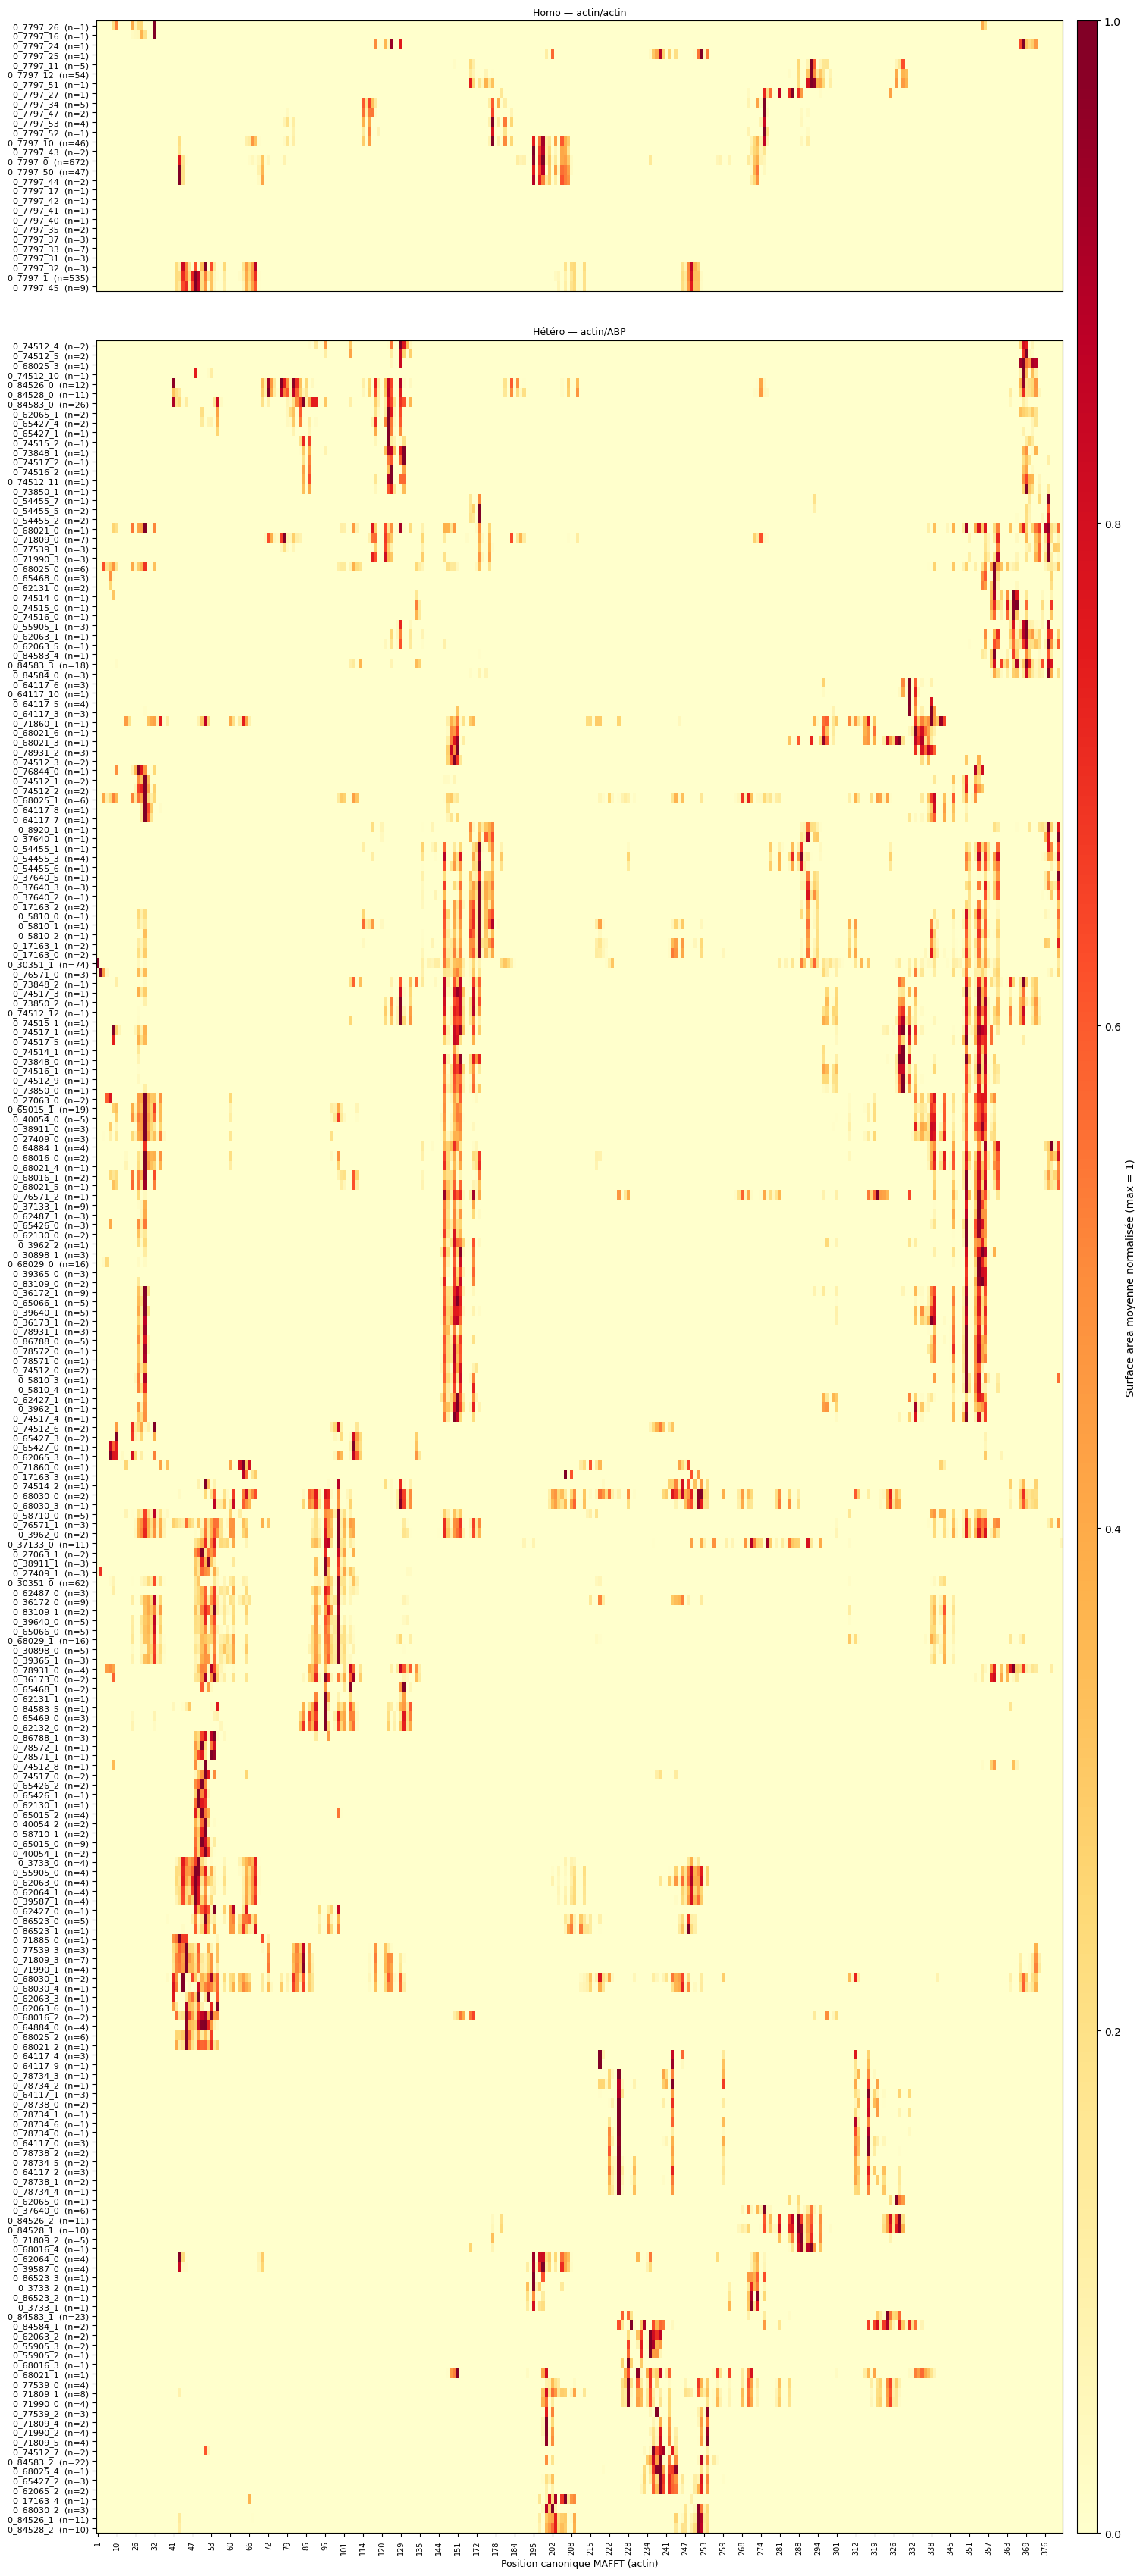

Sauvegardé → ../visualisations/actin_c70_heatmap_surface_area.png


In [10]:
VIS_DIR = Path('../visualisations')

def draw_c70_combined(mat_homo, lbl_homo, mat_hetero, lbl_hetero, out_path):
    n_homo, n_hetero = len(lbl_homo), len(lbl_hetero)
    fig_w = 16.0
    fig_h = (n_homo + n_hetero) * ROW_H + MARGIN_B + MARGIN_T

    fig = plt.figure(figsize=(fig_w, fig_h), facecolor='white')
    gs = plt.GridSpec(
        2, 2, figure=fig,
        left=MARGIN_L/fig_w, right=1-MARGIN_R/fig_w,
        bottom=MARGIN_B/fig_h, top=1-MARGIN_T/fig_h,
        height_ratios=[n_homo, n_hetero],
        hspace=0.04, width_ratios=[1, 0.02], wspace=0.03,
    )
    ax_h  = fig.add_subplot(gs[0, 0])
    ax_e  = fig.add_subplot(gs[1, 0])
    ax_cb = fig.add_subplot(gs[:, 1])

    xticks_idx = list(range(0, len(all_pos), max(1, len(all_pos) // 50)))
    kw = dict(aspect='auto', cmap='YlOrRd', interpolation='none', vmin=0, vmax=1.0)

    im = ax_h.imshow(mat_homo, **kw)
    ax_h.set_yticks(range(n_homo))
    ax_h.set_yticklabels(lbl_homo, fontsize=8)
    ax_h.set_xticks([])
    ax_h.set_title('Homo — actin/actin', fontsize=9)

    ax_e.imshow(mat_hetero, **kw)
    ax_e.set_yticks(range(n_hetero))
    ax_e.set_yticklabels(lbl_hetero, fontsize=8)
    ax_e.set_xticks(xticks_idx)
    ax_e.set_xticklabels([all_pos[i] for i in xticks_idx], fontsize=7, rotation=90)
    ax_e.set_xlabel('Position canonique MAFFT (actin)', fontsize=9)
    ax_e.set_title('Hétéro — actin/ABP', fontsize=9)

    plt.colorbar(im, cax=ax_cb, label='Surface area moyenne normalisée (max = 1)')
    plt.savefig(out_path, dpi=150, facecolor='white')
    plt.show()
    plt.close(fig)
    print(f'Sauvegardé → {out_path}')


draw_c70_combined(mat_homo, lbl_homo, mat_hetero, lbl_hetero,
                  VIS_DIR / 'actin_c70_heatmap_surface_area.png')

## Script PyMOL — surface + b-factor par cluster C70

Génère `view_all_clusters.pml` à ouvrir directement dans PyMOL.

- **Chain A** (S1 / actine) : une seule surface grise de référence, toutes les autres chain A sont cachées après alignement
- **Chain B** (S2 / partenaire) : surface colorée par b-factor → **vert** si ABP (hétéro), **magenta** si actine (homo)

Dépend des PDB générés par `script/bfactor_c70_interface.py` (pipeline étape 8).

In [11]:
import re as _re
from pathlib import Path

PDB_DIR = Path('../data/filtered/details/structures_files/bfactor_c70_interface')
OUT_PML = PDB_DIR / 'view_all_clusters.pml'

# Rôles S1/S2 par cluster (généré par bfactor_c70_interface.py)
_roles_csv = Path('../data/filtered/cluster_s1_s2_roles.csv')
_cluster_s1_sites = {}
if _roles_csv.exists():
    _df_roles = pd.read_csv(str(_roles_csv))
    for _, _r in _df_roles.iterrows():
        _cluster_s1_sites[str(_r['patch'])] = set(
            x for x in str(_r['s1_binding_sites']).split(';') if x
        )

def parse_ids_nb(s):
    s = _re.sub(r'np\.int64\(([0-9]+)\)', r'\1', str(s))
    return {int(x) for x in _re.findall(r'[0-9]+', s)}

def orig_chain_of(pdb_path, bfac_chain):
    """Lit la position 71 du PDB bfactor pour récupérer la chaîne originale."""
    with open(pdb_path) as f:
        for line in f:
            if line.startswith('ATOM') and len(line) > 72 and line[21] == bfac_chain:
                return line[71]
    return ''

def s1_bfac_chain(patch, pdb_path):
    """Retourne la chaîne bfactor (A ou B) correspondant au S1 du cluster.
    Utilise cluster_s1_s2_roles.csv pour identifier le binding site S1 (tous clusters).
    Fallback ancre fixe 6685_1 si CSV absent."""
    s1_sites = _cluster_s1_sites.get(patch, set())
    summ_ids = parse_ids_nb(df_c70[df_c70['patch'] == patch].iloc[0]['ids_interactions'])
    orig_A = orig_chain_of(str(pdb_path), 'A')
    orig_B = orig_chain_of(str(pdb_path), 'B')

    for sid in sorted(summ_ids):
        sub = df_summary[df_summary['interaction_id'] == sid]
        if sub.empty:
            continue
        r_sum = sub.iloc[0]
        all_row = df_all[
            (df_all['subunit_1'] == r_sum['Protein ID']) &
            (df_all['subunit_2'] == r_sum['Interactor ID'])
        ]
        if all_row.empty:
            continue
        s1_site = str(all_row.iloc[0]['s1_binding_site_cluster_data_70'])
        s2_site = str(all_row.iloc[0]['s2_binding_site_cluster_data_70'])
        orig_sumA = r_sum['Protein ID'].split('_')[-1]
        orig_sumB = r_sum['Interactor ID'].split('_')[-1]
        if s1_sites:
            if s1_site in s1_sites:
                return 'A' if orig_A == orig_sumA else 'B'
            elif s2_site in s1_sites:
                return 'A' if orig_A == orig_sumB else 'B'
        else:
            # fallback ancre fixe
            if s1_site == '6685_1':
                return 'A' if orig_A == orig_sumA else 'B'
            elif s2_site == '6685_1':
                return 'A' if orig_A == orig_sumB else 'B'

    return 'A'  # fallback

# ── Génération du script PyMOL ────────────────────────────────────────────────

lines        = []
ref_obj      = None
ref_s1_chain = None
loaded       = swapped = 0

for c in homo_c70 + hetero_c70:
    patch    = str(c['patch'])
    pdb_path = PDB_DIR / f'{patch}.pdb'
    if not pdb_path.exists():
        continue

    obj          = 'p' + patch.replace('-', '_').replace('.', '_')
    cluster_type = str(c['type']).lower()
    abs_path     = pdb_path.resolve()

    s1_chain      = s1_bfac_chain(patch, pdb_path)
    partner_chain = 'B' if s1_chain == 'A' else 'A'
    if s1_chain == 'B':
        swapped += 1

    lines.append(f'load {abs_path}, {obj}')

    if ref_obj is None:
        ref_obj      = obj
        ref_s1_chain = s1_chain
        lines.append(f'hide everything, {obj}')
        lines.append(f'show surface, {obj} and chain {s1_chain}')
        lines.append(f'color deepsalmon, {obj} and chain {s1_chain}')
    else:
        lines.append(f'align {obj} and chain {s1_chain}, {ref_obj} and chain {ref_s1_chain}')
        lines.append(f'hide everything, {obj} and chain {s1_chain}')

    lines.append(f'show surface, {obj} and chain {partner_chain}')
    if cluster_type == 'hetero':
        lines.append(f'spectrum b, white_green,   {obj} and chain {partner_chain}, minimum=0, maximum=100')
    else:
        lines.append(f'spectrum b, white_magenta, {obj} and chain {partner_chain}, minimum=0, maximum=100')

    lines.append('')
    loaded += 1

lines += [
    'set surface_quality, 1',
    'bg_color white',
    'set ray_opaque_background, off',
    'orient',
]

OUT_PML.write_text('\n'.join(lines))
print(f'Script PyMOL généré : {OUT_PML}')
print(f'{loaded} clusters chargés — {swapped} swap(s) détecté(s) via binding site direct')
print(f"CSV rôles S1/S2 chargé : {len(_cluster_s1_sites)} clusters")

Script PyMOL généré : ../data/filtered/details/structures_files/bfactor_c70_interface/view_all_clusters.pml
255 clusters chargés — 5 swap(s) détecté(s) via binding site direct
CSV rôles S1/S2 chargé : 255 clusters
